In [294]:
import matplotlib.pyplot as plt
import scipy.io as sio
import numpy as np
import os

import sys
sys.path.append(os.path.dirname(os.getcwd()))

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# 1. 模型训练和权重

(15000, 128) (15000,)
(129, 5)
(15000, 129)


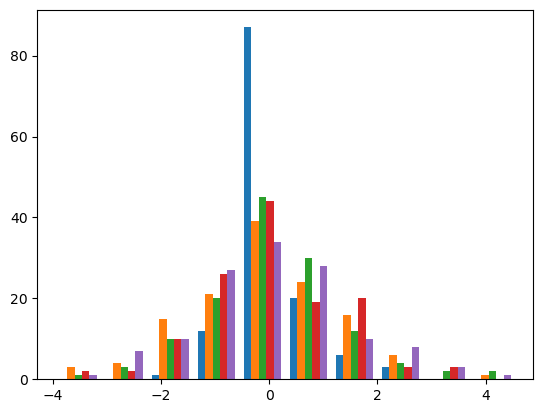

4.5551797491647035 1.0615198950925322


In [295]:
mat_contents = sio.loadmat('../data/svm/train3.mat')
data = mat_contents['train_3']  # 根据实际文件中的变量名调整

# 数据中前128列为特征，最后1列为标签（原始标签取值为 1~5）
X = data[:, :128]  # 特征矩阵，尺寸为 (N, d) 其中 d=128
Y = data[:, 128].flatten()  # 标签向量，尺寸为 (N, )
# 为方便运算，将标签调整到 0~K-1 （K=5）
Y = Y - 1
N,d = X.shape
K = 5
print(X.shape,Y.shape)

# 加载权重数据
Wb=np.load('../data/svm/svm_weight_90.npy').T
W=Wb[:128]
b=Wb[128]
print(Wb.shape)

# 生产新的输入
X_NEW = np.hstack((X, np.ones((N,1))))
print(X_NEW.shape)


plt.hist(Wb)
plt.show()

print(np.max(W),np.max(b))

In [296]:
# # 定义参数网格
# param_grid = {'C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0,20]}

# # 创建线性SVM分类器
# clf = LinearSVC(multi_class='crammer_singer',max_iter=100000)
# # 使用网格搜索
# grid_search = GridSearchCV(clf, param_grid, cv=2, scoring='accuracy')
# grid_search.fit(X, Y)

# # 输出最优参数
# print("最优参数:", grid_search.best_params_)
# print("最优模型的准确率:", grid_search.best_score_)

# ----------------------------------
# clf = LinearSVC(multi_class='crammer_singer', C=9,max_iter=1000000)
# clf.fit(X, Y)

# W,b = clf.coef_,clf.intercept_
# Wb = np.hstack((W, b.reshape(5, 1)))

# np.save('../data/svm/svm_weight_90.npy',Wb)
# plt.hist(Wb)
# plt.show()
# #--------------------------------------
# accuracy = clf.score(X, Y)
# print("测试集上的准确率:", accuracy)

In [297]:
#-------------------------------------
scores_all = np.dot(X, W)+b
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")


scores_all = np.dot(X_NEW, Wb)
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 90.55%
Accuracy = 90.55%


# 2.权重部署

In [298]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import CHIP
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

In [299]:
chip=CHIP(PS(host="192.168.1.11", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("../compiler/code/")

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 56673
正在编译文件:  ../compiler/code/read_point3.txt
正在编译文件:  ../compiler/code/read_point3_col.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


-3.957509136477504 -1.246078962052054
4.5551797491647035 1.0615198950925322


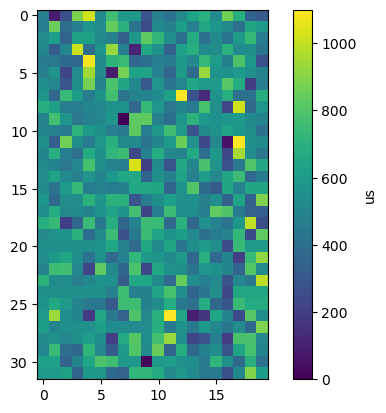

In [300]:
print(np.min(W),np.min(b))
print(np.max(W),np.max(b))
cond_min,cond_max,cond_reference = 0,1100,550
cond_range = cond_max-cond_reference
weight_min,weight_max = -4,4
target_cond = Wb/weight_max*cond_range+cond_reference

plot_cond(target_cond[:128,:].reshape(32,20),vmin=0,vmax=1100,label="us")

66.36581030186794
32.914071875088574


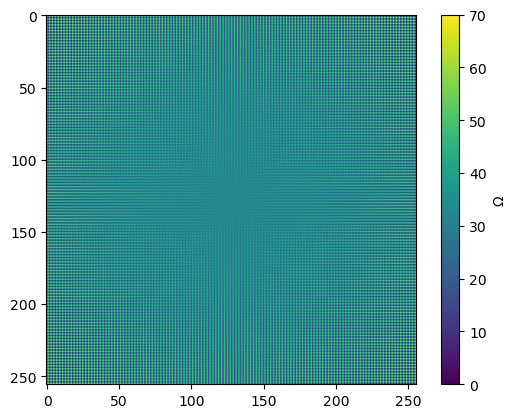

In [301]:
r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy")
r_w_col = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")
r_w_row = np.load("../data/r_out_r_wire/chip_1_4_row_r_wire_0_50_56.npy")
r_w_crossbar = np.zeros((256,256))
for row in range(256):
    for col in range(256):
        r_w_crossbar[row,col] = (255-row)*r_w_col[col] if col%2==0 else row*r_w_col[col]
        r_w_crossbar[row,col] += (255-col)*r_w_row[row] if row%2==1 else col*r_w_row[row]

print(np.max(r_w_crossbar))
print(r_w_crossbar[255,0])
plot_cond(r_w_crossbar,vmin=0,vmax=70,label="Ω")

# 3.选点

### 3.1 set操作

In [ ]:
# def Forming(self,need_read,write_times,write_voltage,start_tg,delta_tg,threshold,
# set_pulse_width,read_type=2,sub_base=False,plot_cond=None):
need_read=np.ones((256,256),dtype=bool)
good_device = np.load("../data/good_point_100_100_1_4.npy")
pos = np.ix_(good_device[0], good_device[1])
need_read[pos] = False

# plot_cond(need_read,vmin=0,vmax=1,label="Ω")
chip.Forming(need_read=need_read,write_times=40,write_voltage=3,start_tg=1.5,delta_tg=0.025,threshold=550,
             set_pulse_width=100e-6,read_type=2,sub_base=True,plot_cond=plot_cond)

In [ ]:
#-------------------------------------------------读
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)

In [ ]:
set_good_device_file_name = "../data/good_device/cond_500_1_4_no_100_100.npy"
reset_good_device_file_name = "../data/good_device/cond_200_1_4_no_100_100.npy"
#-------------------------------------------------好的器件
need_read=np.ones((256,256),dtype=bool)
good_device = np.load("../data/good_point_100_100_1_4.npy")
pos = np.ix_(good_device[0], good_device[1])
need_read[pos] = False
goodset= (cond>500)&need_read
np.save(set_good_device_file_name,goodset)
plot_cond(goodset,vmax=1)

### 3.2 reset操作

In [ ]:
# def Reset(self,need_read,write_times,start_v,delta_v,tg,threshold,reset_pulse_width,read_type=2,
# sub_base=False,vmax=1000,plot_cond=None):
need_read=np.ones((256,256),dtype=bool)
good_device = np.load("../data/good_point_100_100_1_4.npy")
pos = np.ix_(good_device[0], good_device[1])
need_read[pos] = False

# plot_cond(need_read,vmin=0,vmax=1,label="Ω")
chip.Reset(need_read=need_read,write_times=40,start_v=1,delta_v=0.05,tg=5,threshold=200,
           reset_pulse_width=100e-6,read_type=2,sub_base=True,vmax=1000,plot_cond=plot_cond)

In [ ]:
#-------------------------------------------------读
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)

In [ ]:
set_good_device_file_name = "../data/good_device/cond_500_1_4_no_100_100.npy"
reset_good_device_file_name = "../data/good_device/cond_200_1_4_no_100_100.npy"
#-------------------------------------------------好的器件
need_read=np.ones((256,256),dtype=bool)
good_device = np.load("../data/good_point_100_100_1_4.npy")
pos = np.ix_(good_device[0], good_device[1])
need_read[pos] = False
goodreset= (cond<250)&need_read
np.save(reset_good_device_file_name,goodreset)
plot_cond(goodreset,vmax=1)

### 3.3 挑好的点

In [ ]:
cond_200 = np.load(reset_good_device_file_name)
# plot_cond(cond_200,vmax=1)
cond_500 = np.load(set_good_device_file_name)
good_cond = cond_200&cond_500
plot_cond(good_cond,vmax=1)
print(np.sum(good_cond))

In [ ]:
# 可以选最大的0-100行里面的5列
col = np.sum(good_cond,axis=0)
col = np.argsort(col)[-20:]
col = np.sort(col)
print(col)
# col = np.array([246,247,248,249,250])


row = good_cond[:, col]
row = np.sum(row,axis=1)
row = np.argsort(row)[50:]
row = np.sort(row)[3:132]
print(np.diff(row))

print("选择的行",row.shape,row)
print("选择的列",col.shape,col)

sub_matrix = good_cond[np.ix_(row, col[:5])]
print(np.sum(sub_matrix))
plot_cond(sub_matrix,vmax=1)

In [ ]:
np.savez("../data/svm/svm_weight_pos",row=row,col=col[:5])

# 4.写权重

In [302]:
tg_map = np.array([1.5,1.55,1.6,1.65,1.7,1.75,1.8])
cond_map = np.array([350,390,450,490,550,590,650])
slope,intercept = np.polyfit(cond_map,tg_map, 1)

In [303]:
svm_weight_pos = np.load("../data/svm/svm_weight_pos.npz")
good_device = [np.array(svm_weight_pos["row"]),np.array(svm_weight_pos["col"])]
pos = np.ix_(good_device[0], good_device[1])

In [534]:
threshold = 100


set_v,reset_v = 0.8,1.5
reset_pulse_width,set_pulse_width = 1000e-6,1000e-6

need_read = np.zeros((256,256),dtype=bool)
need_read[pos] = True

    
target = np.ones((256,256))
target[pos] = target_cond

tg_v = target*slope+intercept-0.4



for i in range(20):
    voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    r = chip.voltage_to_resistance(voltage=voltage-voltage_base)*1e3
    r-=r_w_crossbar
    cond = 1/r*1e6
    
    # plot_cond((cond[pos]-cond_reference).T,vmin=-cond_range,vmax=cond_range)

    condition_reset = (cond > (target+threshold)) & need_read
    condition_set = (cond < (target-threshold)) & need_read
    print(cond[condition_reset])
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))
# 
    if i>0:
        # set_v = set_v+0.05
        # if i<5:
        #     tg_v[condition_reset] -= 0.04
        #     tg_v[condition_set] += 0.04
        # elif i<10:
        #     tg_v[condition_reset] -= 0.02
        #     tg_v[condition_set] += 0.02
        # else:
        tg_v[condition_reset] -= 0.04
        tg_v[condition_set] += 0.02

    tg_v.clip(0,3,out=tg_v)

    chip.write_point2(crossbar=condition_reset,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
    # chip.write_point2(crossbar=condition_reset,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)
    # # chip.ps.set_time_out(100)
    # chip.write_point2(crossbar=condition_set,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


[]
0 reset: 0 set 14
[]
1 reset: 0 set 14
[]
2 reset: 0 set 14
[]
3 reset: 0 set 14
[]
4 reset: 0 set 14
[]
5 reset: 0 set 14
[]
6 reset: 0 set 14
[]
7 reset: 0 set 14
[]
8 reset: 0 set 14
[]
9 reset: 0 set 14
[]
10 reset: 0 set 14
[]
11 reset: 0 set 14
[]
12 reset: 0 set 14
[]
13 reset: 0 set 14
[]
14 reset: 0 set 14
[]
15 reset: 0 set 14
[]
16 reset: 0 set 14
[]
17 reset: 0 set 14
[]
18 reset: 0 set 14
[]
19 reset: 0 set 14


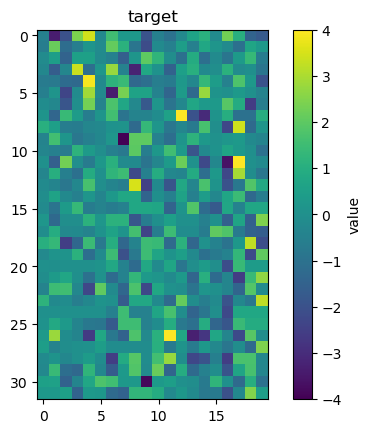

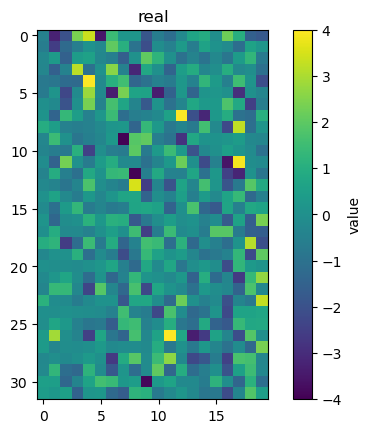

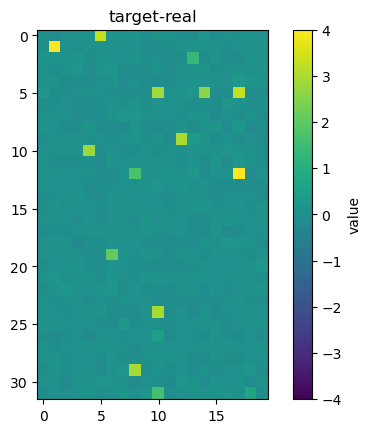

In [529]:
need_read = np.zeros((256,256),dtype=bool)
need_read[pos] = True
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
r = chip.voltage_to_resistance(voltage=voltage-voltage_base)*1e3
r-=r_w_crossbar
cond = (1/r*1e6)[pos]
np.save("../data/svm/cond_sub_base_20250430.npy",cond)
cond = cond -cond_reference

W1 = cond/cond_range*weight_max

plot_cond(W[:128,:].reshape(32,20),vmin=-4,vmax=4,label="value",title="target")
plot_cond(W1[:128,:].reshape(32,20),vmin=-4,vmax=4,label="value",title="real")

plot_cond(W[:128,:].reshape(32,20)-W1[:128,:].reshape(32,20),vmin=-4,vmax=4,label="value",title="target-real")
# plot_cond(.reshape(32,20),vmin=-4,vmax=4,label="value")
# plot_cond(data[:128,:].reshape(32,20)-W[:128,:].reshape(32,20),vmin=weight_min,vmax=weight_max,label="value")



In [535]:
scores_all = np.dot(X_NEW, W1)
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 86.59%


# 5.读出来的权重做推理

In [ ]:
r_out = np.load("../data/r_out_r_wire/chip_1_4_col_r_out_0_50_56_times=2.npy")
r_w_col = np.load("../data/r_out_r_wire/chip_1_4_col_r_wire_0_50_56_times=2.npy")
r_w_row = np.load("../data/r_out_r_wire/chip_1_4_row_r_wire_0_50_56.npy")

In [ ]:
need_read = np.zeros((256,256),dtype=bool)
need_read[pos] = True
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
r = chip.voltage_to_resistance(voltage=voltage-voltage_base)*1e3
r-=r_w_crossbar
real_cond = (1/r*1e6)[pos]
real_mean = np.mean(real_cond,axis=0)
print(real_mean)

In [ ]:
change256 = np.zeros((129,3))

for i in range(129):
    print(i,end=" ")
    num=4
    col = good_device[1][num]

    need_read = np.zeros((256,256),dtype=bool)
    row_index = good_device[0][:i+1]

    weight_pos = np.ix_(row_index,[col])
    need_read[weight_pos] = True

    min_row,max_row = np.min(row_index),np.max(row_index)
    wire_r = (255-max_row)*r_w_col[i] if col%2==0 else (min_row)*r_w_col[i]
    row_nums = len(row_index)

    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)

    real_r = chip.voltage_to_resistance(voltage = voltage)[0,col]*1e3 - r_out[col] - wire_r - r_w_col[col]*(i**0.785)
    cond = 1/real_r*1e6


    n = len(row_index)
    a = (n*(n-1)/2)
    b = n+n*(n+1)*(n-1)/6*(r_w_col[col]+r_w_col[col]**2+r_w_col[col]**3)/(real_mean[num])
    # print(a/b*r_w_col[col],r_w_col[col]*(i**0.785))
    real_r = chip.voltage_to_resistance(voltage = voltage)[0,col]*1e3 - r_out[col] - wire_r - a/b*r_w_col[col]
    cond2 = 1/real_r*1e6


    change256[i,0]=np.sum(real_cond[:i+1,num])        # 正常读
    change256[i,1]=cond             # 
    change256[i,2]=cond2

In [ ]:
print(col)
plt.plot(change256[:,0],label = "real")
plt.plot(change256[:,1],label = "Compensation1")
plt.plot(change256[:,2],label ="Compensation2")
ans = change256[:,0]-change256[:,1]
plt.title("col="+str(col))
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

In [428]:
need_read = np.zeros((256,256),dtype=bool)
def forward_unsigned_from_row(chip,row_index,col_index,r_w_col,r_out,forward_type=1,value = 0.785):
    """
        从行给信号进行推理
    """
    col_nums,row_nums = len(col_index),len(row_index)
    from_row = True
    if col_nums <= 0:
        return np.zeros((len(row_index),1))
    
    min_row,max_row = np.min(row_index),np.max(row_index)
    row_rw = np.array([(256-max_row)*r_w_col[i] if i%2==0 else (min_row)*r_w_col[i] for i in col_index])
    gain = 1 if row_nums<=10 else 3
    if forward_type==1:
        # -------------------------------------
        # voltage_base = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
        #                                             read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0,compute=True
        #                                         # ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
        #                                         # ,tia_split=[0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,]
        #                                         # ,tia_split=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,]
        #                                         )
        voltage = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                            read_voltage=0.1,tg=5,gain=gain, from_row=from_row,out_type=0,compute=True
                                            # ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                            # ,tia_split=[0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,]
                                            # ,tia_split=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,]
                                            )
        parallel_r = chip.voltage_to_resistance(voltage = voltage)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w_col[col_index]/(col_nums/(max_row-min_row+1))*(row_nums**value)
        # 单位A
        parallel_i = 1/parallel_r - cond_reference*1e-6*row_nums
        parallel_value = parallel_i/(cond_range*1e-6)*weight_max
        return parallel_value.flatten()
    elif forward_type==2:
        need_read[:]=False
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True

        # voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
        voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
        not_parallel_r = chip.voltage_to_resistance(voltage = voltage)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w_col[col_index]/(col_nums/(max_row-min_row+1))*(row_nums**value)
        # 单位A
        not_parallel_i = 1/not_parallel_r - cond_reference*1e-6*row_nums
        not_parallel_value = not_parallel_i/(cond_range*1e-6)*weight_max
        return not_parallel_value.flatten()
    elif forward_type==3:
        need_read[:]=False
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=from_row,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=from_row,out_type=0)
        r = chip.voltage_to_resistance(voltage=voltage-voltage_base)*1e3
        r-=r_w_crossbar
        cond = (1/r*1e6)[weight_pos]

        # 单位A
        real_i =np.sum(cond,axis=0) - cond_reference*row_nums
        real_value = real_i/(cond_range)*weight_max
        return real_value.flatten()
    

In [429]:
# 两个100个元素的列表
svm_weight_pos = np.load("../data/svm/svm_weight_pos.npz")
good_device = [np.array(svm_weight_pos["row"]),np.array(svm_weight_pos["col"])]

def forward_from_row_svm(chip,x,col_index,r_w_col,r_out,interval,forward_type = 3,value=0.785):
    """
        x只有3个值,0,1,2
        单列输出用0.785
    """
    y = np.zeros((len(col_index)))
    x = x.flatten()
    
    row_index = good_device[0][np.where(x > 1.5)]
    row_nums = len(row_index)
    steps = math.ceil(row_nums/interval)
    if row_nums>0:
        for i in range(steps):
            y += forward_unsigned_from_row(chip,row_index[i*interval:min((i+1)*interval,row_nums)],col_index,r_w_col,r_out,forward_type=forward_type,value=value)
    

    row_index = good_device[0][np.where(x > 0.5)]
    row_nums = len(row_index)
    if row_nums>0:
        steps = math.ceil(row_nums/interval)
        for i in range(steps):
            y += forward_unsigned_from_row(chip,row_index[i*interval:min((i+1)*interval,row_nums)],col_index,r_w_col,r_out,forward_type=forward_type,value=value)

    return y

In [261]:
select_num = 15000
rows_to_select = np.random.choice(X_NEW.shape[0], select_num, replace=False)
X_SELECT = X_NEW[rows_to_select, :]
Y_SELECT = Y[rows_to_select]
print(X_SELECT.shape,Y_SELECT.shape)

(15000, 129) (15000,)


In [430]:
scores_all = np.zeros((select_num,5))

for i in range(select_num):
    scores_all[i,:]=forward_from_row_svm(chip,X_NEW[i],col_index=good_device[1],r_w_col=r_w_col,r_out=r_out,interval=129,forward_type=2,value=0.785)

y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 86.33%


In [ ]:
# np.save("../data/svm/scores_all_15000.npy",scores_all)

In [456]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import Identity, Zeros
import numpy as np

In [454]:
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 86.33%


In [457]:
Y_NEW = np.eye(5)[Y]
# 定义单层MLP网络
model = Sequential([
    Dense(5, input_shape=(5,), activation='softmax', 
          kernel_initializer=Identity(),  # 权重初始化为对角线全为1的矩阵
          bias_initializer=Zeros())      # 偏置初始化为0
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [458]:
# 训练模型
scores_all=np.load("../data/svm/scores_all_15000.npy")
history = model.fit(scores_all, Y_NEW, epochs=40, batch_size=64)

# 评估模型
test_loss, test_accuracy = model.evaluate(scores_all, Y_NEW)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step - accuracy: 0.8606 - loss: 99.4227
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.8689 - loss: 31.8682
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.8604 - loss: 191.1745
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.8593 - loss: 58.1497
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.8608 - loss: 78.2360
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.8585 - loss: 23.7816
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - accuracy: 0.8595 - loss: 28.1089
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - accuracy: 0.8587 - loss: 69.7751
Epoch 9/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.8566 - loss: 216.1678
Epoch 10/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.8535 - loss: 70.2290
Epoch 11/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - accuracy: 0.8507 - loss: 98.7608 
Epoch 12/40
235/

In [459]:
test_loss, test_accuracy = model.evaluate(scores_all, Y_NEW)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.6337 - loss: 1.9381
Test Loss: 1.9976
Test Accuracy: 0.4929


In [464]:
weights_and_biases = model.get_weights()

W_T = weights_and_biases[0]

b_T = weights_and_biases[1]
np.save("../data/svm/W_T.npy",W_T)
np.save("../data/svm/b_T.npy",b_T)
data_scores = np.load("../data/svm/scores_all_15000.npy")
z=np.dot(data_scores,W_T)+b_T
y_pred = tf.nn.softmax(z).numpy()
y_pred = np.argmax(y_pred, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 49.29%


In [337]:
# scores_all = np.dot(X_NEW, Wb)
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 79.08%


# 6.计算伪逆

In [536]:
beset_score = np.dot(X_NEW, Wb)
y_pred = np.argmax(beset_score, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 90.55%


In [540]:
hard_score = np.load("../data/svm/scores_all_15000.npy")
y_pred = np.argmax(hard_score, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")
A_pinv = np.linalg.pinv(hard_score)
W_pinv = np.dot(A_pinv,beset_score)

Accuracy = 86.33%


In [538]:
hard_score_pinv = np.dot(hard_score,W_pinv)
y_pred = np.argmax(hard_score_pinv, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 25.22%


In [539]:
W_T=np.load("../data/svm/W_T.npy")
b_T=np.load("../data/svm/b_T.npy")

hard_score = np.load("../data/svm/scores_all_15000.npy")
z=np.dot(hard_score,W_T)+b_T

y_pred = np.argmax(z, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

Accuracy = 49.29%
